63 lefty relievers with 30+ IP
Metrics at 90th percentile or higher: ['Pitching+', 'Stuff+', 'SIERA', 'xFIP-', 'xFIP', 'FIP', 'Location+', 'K-BB%', 'K/BB', 'FIP-']


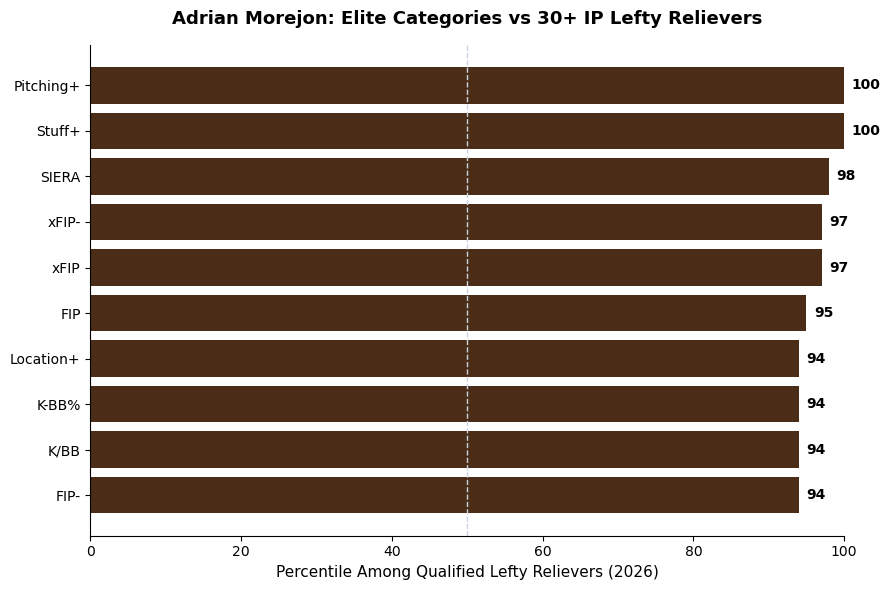

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

f10 = pd.read_csv('Morejon Data/fangraphs-leaderboards (10).csv')
f11 = pd.read_csv('Morejon Data/fangraphs-leaderboards (11).csv')
f12 = pd.read_csv('Morejon Data/fangraphs-leaderboards (12).csv')
f13 = pd.read_csv('Morejon Data/fangraphs-leaderboards (13).csv')

merged = f11.merge(f10[['MLBAMID','Stuff+','Location+','Pitching+']], on='MLBAMID', how='left')
merged = merged.merge(f12[['MLBAMID','SV','HLD','IP','G']], on='MLBAMID', how='left')
merged = merged.merge(f13[['MLBAMID','WPA','WPA/LI','Clutch','pLI']], on='MLBAMID', how='left')

merged = merged[merged['IP'] >= 30].copy()
print(merged.shape[0], "lefty relievers with 30+ IP")

morejon_row = merged[merged['Name']=='Adrian Morejon'].iloc[0]

metrics = {
    "Pitching+": ("Pitching+", False),
    "Stuff+": ("Stuff+", False),
    "Location+": ("Location+", False),
    "K-BB%": ("K-BB%", False),
    "K%": ("K%", False),
    "K/9": ("K/9", False),
    "K/BB": ("K/BB", False),
    "FIP-": ("FIP-", True),
    "xFIP-": ("xFIP-", True),
    "SIERA": ("SIERA", True),
    "FIP": ("FIP", True),
    "xFIP": ("xFIP", True),
    "BB/9": ("BB/9", True),
    "HR/9": ("HR/9", True),
    "WHIP": ("WHIP", True),
    "AVG": ("AVG", True),
    "WPA/LI": ("WPA/LI", False),
    "WPA": ("WPA", False),
    "Clutch": ("Clutch", False),
}

results = {}
for label, spec in metrics.items():
    col, lower_is_better = spec
    values = merged[col].dropna()
    if pd.isna(morejon_row[col]):
        continue
    pct = percentileofscore(values, morejon_row[col])
    if lower_is_better:
        pct = 100 - pct
    results[label] = round(pct)

results = {k: v for k, v in results.items() if v >= 90}
results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
labels = list(results.keys())
values = list(results.values())

print("Metrics at 90th percentile or higher:", labels)

brown = "#4a2c17"

fig, ax = plt.subplots(figsize=(9, max(4, len(labels) * 0.6)))
fig.patch.set_facecolor("white")
bars = ax.barh(labels, values, color=brown)
ax.set_xlim(0, 100)
ax.set_xlabel("Percentile Among Qualified Lefty Relievers (2026)", fontsize=11)
title_text = "Adrian Morejon: Elite Categories vs 30+ IP Lefty Relievers"
ax.set_title(title_text, fontsize=13, fontweight="bold", pad=15)
ax.invert_yaxis()
ax.axvline(50, color="#cbd5e1", linewidth=1, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("morejon_elite_categories.png", dpi=200, bbox_inches="tight")
plt.show()